# ResNet-UNet

This notebook uses the shared preprocessing notebook before defining the model.

In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


from torchvision.models import resnet34, ResNet34_Weights

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)


torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")
print(f"Using torch version: {torch.__version__}")

Using device: cpu
Using torch version: 2.13.0


In [3]:
# running preprocessing notebook

%run ../shared/preprocessing.ipynb

In [4]:
# Creating Data Loaders

train_loader, val_loader, test_loader, pos_weight = get_dataloaders( # type: ignore
    data_dir=DEFAULT_DATA_DIR, # type: ignore
    batch_size=32,
    augment_train=True,
    num_workers=0,
)

print("Input channels:", NUM_CHANNELS) # type: ignore
print("Positive-class weight:", pos_weight)
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

I0000 00:00:1790388248.890432 4100013 tf_record_dataset_op.cc:390] TFRecordDataset `buffer_size` is unspecified, default to 262144


Input channels: 12
Positive-class weight: 20.0
Train batches: 469
Validation batches: 59
Test batches: 53


In [5]:
inputs, targets, valid_mask = next(iter(train_loader))

print("Inputs: ", inputs.shape, inputs.dtype)
print("Targets: ", targets.shape, targets.dtype)
print("Valid mask: ", valid_mask.shape, valid_mask.dtype)

print("Target values: ", torch.unique(targets))
print("Mask values: ", torch.unique(valid_mask))

assert inputs.shape[1:] == (12, 64, 64)
assert targets.shape[1:] == (1, 64, 64)
assert valid_mask.shape == targets.shape
assert torch.isfinite(inputs).all()

print("Data contract verified successfully.")

Inputs:  torch.Size([32, 12, 64, 64]) torch.float32
Targets:  torch.Size([32, 1, 64, 64]) torch.float32
Valid mask:  torch.Size([32, 1, 64, 64]) torch.float32
Target values:  tensor([-1.,  0.,  1.])
Mask values:  tensor([0., 1.])
Data contract verified successfully.


# Build ResNet34–UNet

## Decoder Block

In [6]:
class DecoderBlock(nn.Module):
    def __init__(self, input_channels, skip_channels, output_channels):
        super().__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(
                input_channels + skip_channels,
                output_channels,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                output_channels,
                output_channels,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(inplace=True),
        )
    
    def forward(self, x, skip):
        # Make x the sme height and width as skip feature
        
        x = F.interpolate(
            x,
            size=skip.shape[2:],
            mode="bilinear",
            align_corners=False,
        )
        
        # join detailed encoder features with upsampled decoder features
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

## Full Model

In [7]:
class ResNet34UNet(nn.Module):
    def __init__(self, input_channels=12):
        super().__init__()
        
        #Load renNet34 with Imagenet-trained weights
        self.encoder = resnet34(
            weights= ResNet34_Weights.IMAGENET1K_V1
        )
        
        # It's original first convolution accepts 3 RGB channels
        old_conv = self.encoder.conv1
        
        # Replace it with a convolution that accepts our 12 features
        new_conv = nn.Conv2d(
            input_channels,
            64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False,
        )
        
        # Initiate the new convolution from the pretrained RGB weights
        with torch.no_grad():
            rgb_average = old_conv.weight.mean(dim=1, keepdim=True)
            new_weights = rgb_average.repeat(
                1,
                input_channels,
                1,
                1
            ) * (3 / input_channels)
            
            new_conv.weight.copy_(new_weights)
            
            
        self.encoder.conv1 = new_conv
        
        # The classification layer is not needed for segmentation
        self.encoder.fc = nn.Identity() # type: ignore
        
        # Decorder: small features maps become layer step by step
        
        self.up4 = DecoderBlock(512, 256, 256)
        self.up3 = DecoderBlock(256, 128, 128)
        self.up2 = DecoderBlock(128, 64, 64)
        self.up1 = DecoderBlock(64, 64, 64)
        self.up0 = DecoderBlock(64, input_channels, 32)
        
        # One output value for each pixel: fire prediction logit.
        self.output_conv = nn.Conv2d(32, 1, kernel_size=1)
    
    
    def forward(self, x):
        original_inputs = x  # Save the 12-channel, 64 × 64 input

        skip0 = self.encoder.relu(
            self.encoder.bn1(self.encoder.conv1(x))
        )                                                  # 32 × 32

        skip1 = self.encoder.layer1(
            self.encoder.maxpool(skip0)
        )                                                  # 16 × 16
        skip2 = self.encoder.layer2(skip1)                 # 8 × 8
        skip3 = self.encoder.layer3(skip2)                 # 4 × 4
        bottom = self.encoder.layer4(skip3)                # 2 × 2

        x = self.up4(bottom, skip3)                        # 4 × 4
        x = self.up3(x, skip2)                             # 8 × 8
        x = self.up2(x, skip1)                             # 16 × 16
        x = self.up1(x, skip0)                             # 32 × 32
        x = self.up0(x, original_inputs)                   # 64 × 64

        return self.output_conv(x)
    

## Building Model

In [8]:
model = ResNet34UNet(input_channels=NUM_CHANNELS).to(device) # type: ignore
model.eval()

with torch.no_grad():
    predictions = model(inputs[:2].to(device))

print("Model output:", predictions.shape)
print("Target shape:", targets[:2].shape)

Model output: torch.Size([2, 1, 64, 64])
Target shape: torch.Size([2, 1, 64, 64])


# Verify the loss

## Define the loss

In [9]:
def masked_bce_dice_loss(logits, targets, valid_mask, pos_weight):
    # BCE accepts only targets from 0 to 1.
    # Give uncertain (-1) pixels a temporary value of 0.
    safe_targets = torch.where(
        valid_mask == 1,
        targets,
        torch.zeros_like(targets),
    )

    # Give fire pixels the weight calculated from training data.
    fire_weight = torch.tensor(
        pos_weight,
        dtype=logits.dtype,
        device=logits.device,
    ).view(1, 1, 1, 1)

    # Calculate BCE separately for each pixel so we can mask pixels afterward.
    bce_per_pixel = F.binary_cross_entropy_with_logits(
        logits,
        safe_targets,
        pos_weight=fire_weight,
        reduction="none",
    )

    bce_loss = (
        (bce_per_pixel * valid_mask).sum()
        / valid_mask.sum().clamp_min(1)
    )

    # Dice compares predicted fire areas with actual fire areas.
    probabilities = torch.sigmoid(logits)
    overlap = (probabilities * safe_targets * valid_mask).sum()

    predicted_fire = (probabilities * valid_mask).sum()
    actual_fire = (safe_targets * valid_mask).sum()

    dice_score = (2 * overlap + 1) / (
        predicted_fire + actual_fire + 1
    )
    dice_loss = 1 - dice_score

    return bce_loss + 0.5 * dice_loss

## Prove that an uncertain pixel is ignored

In [10]:
example_logits = torch.tensor(
    [[[[0.2, -0.3, 0.5]]]],
    requires_grad=True,
)
example_targets = torch.tensor([[[[1.0, 0.0, -1.0]]]])
example_mask = torch.tensor([[[[1.0, 1.0, 0.0]]]])

loss_before = masked_bce_dice_loss(
    example_logits, example_targets, example_mask, pos_weight
)

changed_logits = example_logits.detach().clone()
changed_logits[0, 0, 0, 2] = 10.0  # Change only the uncertain pixel

loss_after = masked_bce_dice_loss(
    changed_logits, example_targets, example_mask, pos_weight
)

assert torch.allclose(loss_before, loss_after)

loss_before.backward()
assert example_logits.grad[0, 0, 0, 2].item() == 0.0 # type: ignore

print("Uncertain-pixel masking works.")

Uncertain-pixel masking works.


## Check the loss with  real model and batch

In [11]:
model.eval()
model.zero_grad(set_to_none=True)

batch_inputs = inputs[:2].to(device)
batch_targets = targets[:2].to(device)
batch_mask = valid_mask[:2].to(device)

logits = model(batch_inputs)

loss = masked_bce_dice_loss(
    logits, batch_targets, batch_mask, pos_weight
)

assert torch.isfinite(loss)
loss.backward()

gradient = model.output_conv.weight.grad
assert gradient is not None
assert torch.isfinite(gradient).all()

print("Loss:", loss.item())

model.zero_grad(set_to_none=True)

Loss: 1.1757018566131592


# Full Model Training

## Make smaller batches from the data

In [12]:
from torch.utils.data import DataLoader
from pathlib import Path
import time



BATCH_SIZE = 8


training_batches = DataLoader(
    train_loader.dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

validation_batches = DataLoader(
    val_loader.dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

print("Training device:", device)
print("Training batches:", len(training_batches))
print("Validation batches:", len(validation_batches))

Training device: cpu
Training batches: 1873
Validation batches: 235


## Define one training epoch

In [13]:
def train_one_epoch(optimizer, encoder_frozen):
    model.train()
    
    if encoder_frozen:
        model.encoder.eval()  # Freeze encoder during training
    
    total_loss = 0.0
    
    for batch_inputs, batch_targets, batch_mask in training_batches:
        batch_inputs = batch_inputs.to(device)
        batch_targets = batch_targets.to(device)
        batch_mask = batch_mask.to(device)

        optimizer.zero_grad()
        
        logits = model(batch_inputs)
        
        loss = masked_bce_dice_loss(
            logits, batch_targets, batch_mask, pos_weight
        )
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * batch_inputs.size(0)
    
    return total_loss / len(training_batches.dataset) # type: ignore

## Measure validation loss and AUPRC

In [14]:
def pixel_auprc(labels, probabilities):
    # Examine pixels from highest predicted fire probability to lowest.
    order = np.argsort(-probabilities, kind="stable")
    sorted_labels = labels[order]
    sorted_probabilities = probabilities[order]

    total_fire_pixels = int(sorted_labels.sum())
    if total_fire_pixels == 0:
        raise ValueError("Validation data contains no fire pixels.")

    # Count correctly identified fire pixels as we move down the list.
    true_positives = np.cumsum(sorted_labels, dtype=np.int64)

    # Calculate once at the end of each group with the same probability.
    group_ends = np.r_[
        sorted_probabilities[1:] != sorted_probabilities[:-1],
        True,
    ]

    precision = true_positives[group_ends] / (
        np.flatnonzero(group_ends) + 1
    )
    recall = true_positives[group_ends] / total_fire_pixels

    return float(
        np.sum(np.diff(np.r_[0.0, recall]) * precision)
    )

In [15]:
@torch.no_grad()
def validate_model():
    model.eval()

    total_loss = 0.0
    all_labels = []
    all_probabilities = []

    for batch_inputs, batch_targets, batch_mask in validation_batches:
        logits = model(batch_inputs.to(device))

        loss = masked_bce_dice_loss(
            logits,
            batch_targets.to(device),
            batch_mask.to(device),
            pos_weight,
        )
        total_loss += loss.item() * batch_inputs.size(0)

        # Keep only pixels with known targets: 0 or 1.
        valid_pixels = batch_mask.bool()
        probabilities = torch.sigmoid(logits).cpu()

        all_labels.append(
            batch_targets[valid_pixels].numpy().astype(np.uint8)
        )
        all_probabilities.append(
            probabilities[valid_pixels].numpy()
        )

    labels = np.concatenate(all_labels)
    probabilities = np.concatenate(all_probabilities)

    val_loss = total_loss / len(validation_batches.dataset) # type: ignore
    val_auprc = pixel_auprc(labels, probabilities)

    return val_loss, val_auprc

## Train a stage and save improvements

In [16]:
results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

checkpoint_path = results_dir / "resnet_unet_best.pt"

history = {
    "stage": [],
    "train_loss": [],
    "val_loss": [],
    "val_auprc": [],
}


def train_stage(stage_name, epochs, optimizer, encoder_frozen,
                best_auprc, patience):
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(optimizer, encoder_frozen)
        val_loss, val_auprc = validate_model()

        history["stage"].append(stage_name)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_auprc"].append(val_auprc)

        print(
            f"{stage_name} | epoch {epoch:02d} | "
            f"train loss {train_loss:.4f} | "
            f"val loss {val_loss:.4f} | "
            f"val AUPRC {val_auprc:.5f}"
        )

        if val_auprc > best_auprc:
            best_auprc = val_auprc
            epochs_without_improvement = 0

            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "val_auprc": best_auprc,
                    "stage": stage_name,
                    "epoch": epoch,
                },
                checkpoint_path,
            )
            print("  Saved a better checkpoint.")
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print("Stopped: validation AUPRC did not improve.")
            break

    return best_auprc

In [17]:
# training_started = time.perf_counter()
# best_auprc = -1.0

# # Stage A: train the decoder while ResNet34 is frozen.
# for parameter in model.encoder.parameters():
#     parameter.requires_grad = False

# decoder_parameters = [
#     parameter
#     for name, parameter in model.named_parameters()
#     if not name.startswith("encoder.")
# ]

# warmup_optimizer = torch.optim.AdamW(
#     decoder_parameters,
#     lr=0.001,
# )

# best_auprc = train_stage(
#     stage_name="decoder warm-up",
#     epochs=3,
#     optimizer=warmup_optimizer,
#     encoder_frozen=True,
#     best_auprc=best_auprc,
#     patience=3,
# )

# # Begin fine-tuning from the best warm-up epoch.
# saved = torch.load(checkpoint_path, map_location=device, weights_only=True)
# model.load_state_dict(saved["model_state_dict"])

# # Stage B: train ResNet34 too, using a smaller learning rate.
# for parameter in model.encoder.parameters():
#     parameter.requires_grad = True

# finetune_optimizer = torch.optim.AdamW(
#     [
#         {"params": model.encoder.parameters(), "lr": 0.00001},
#         {"params": decoder_parameters, "lr": 0.0001},
#     ]
# )

# best_auprc = train_stage(
#     stage_name="fine-tuning",
#     epochs=40,
#     optimizer=finetune_optimizer,
#     encoder_frozen=False,
#     best_auprc=best_auprc,
#     patience=8,
# )

# training_seconds = time.perf_counter() - training_started
# print(f"Best validation AUPRC: {best_auprc:.5f}")
# print(f"Training time: {training_seconds / 60:.1f} minutes")
# print("Best checkpoint:", checkpoint_path)

In [18]:
# import matplotlib.pyplot as plt

# epochs_completed = range(1, len(history["train_loss"]) + 1)

# plt.figure(figsize=(12, 4))

# plt.subplot(1, 2, 1)
# plt.plot(epochs_completed, history["train_loss"], label="Training")
# plt.plot(epochs_completed, history["val_loss"], label="Validation")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.title("Training and validation loss")
# plt.legend()

# plt.subplot(1, 2, 2)
# plt.plot(epochs_completed, history["val_auprc"])
# plt.xlabel("Epoch")
# plt.ylabel("AUPRC")
# plt.title("Validation pixel AUPRC")

# plt.tight_layout()
# plt.show()

# Validation Review

## Load the best checkpoint

In [19]:
saved = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=True,
)

model.load_state_dict(saved["model_state_dict"])
model.eval()

print("Best stage:", saved["stage"])
print("Best epoch in that stage:", saved["epoch"])
print("Best validation AUPRC:", saved["val_auprc"])

Best stage: fine-tuning
Best epoch in that stage: 9
Best validation AUPRC: 0.28175205460094155


## validation results

In [20]:
THRESHOLD = 0.5

true_positive = 0
false_positive = 0
false_negative = 0
true_negative = 0

with torch.no_grad():
    for batch_inputs, batch_targets, batch_mask in validation_batches:
        logits = model(batch_inputs.to(device))
        probabilities = torch.sigmoid(logits).cpu()

        predicted_fire = probabilities >= THRESHOLD
        actual_fire = batch_targets == 1
        valid = batch_mask == 1

        true_positive += int(
            (predicted_fire & actual_fire & valid).sum()
        )
        false_positive += int(
            (predicted_fire & ~actual_fire & valid).sum()
        )
        false_negative += int(
            (~predicted_fire & actual_fire & valid).sum()
        )
        true_negative += int(
            (~predicted_fire & ~actual_fire & valid).sum()
        )

precision = (
    true_positive / (true_positive + false_positive)
    if true_positive + false_positive > 0 else 0.0
)
recall = (
    true_positive / (true_positive + false_negative)
    if true_positive + false_negative > 0 else 0.0
)
f1 = (
    2 * precision * recall / (precision + recall)
    if precision + recall > 0 else 0.0
)
iou = (
    true_positive / (true_positive + false_positive + false_negative)
    if true_positive + false_positive + false_negative > 0 else 0.0
)

print("True positive: ", true_positive)
print("False positive:", false_positive)
print("False negative:", false_negative)
print("True negative: ", true_negative)
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")
print(f"Fire IoU:  {iou:.4f}")

True positive:  61733
False positive: 219576
False negative: 40861
True negative:  7178215
Precision: 0.2194
Recall:    0.6017
F1:        0.3216
Fire IoU:  0.1916


## validation patch with fire

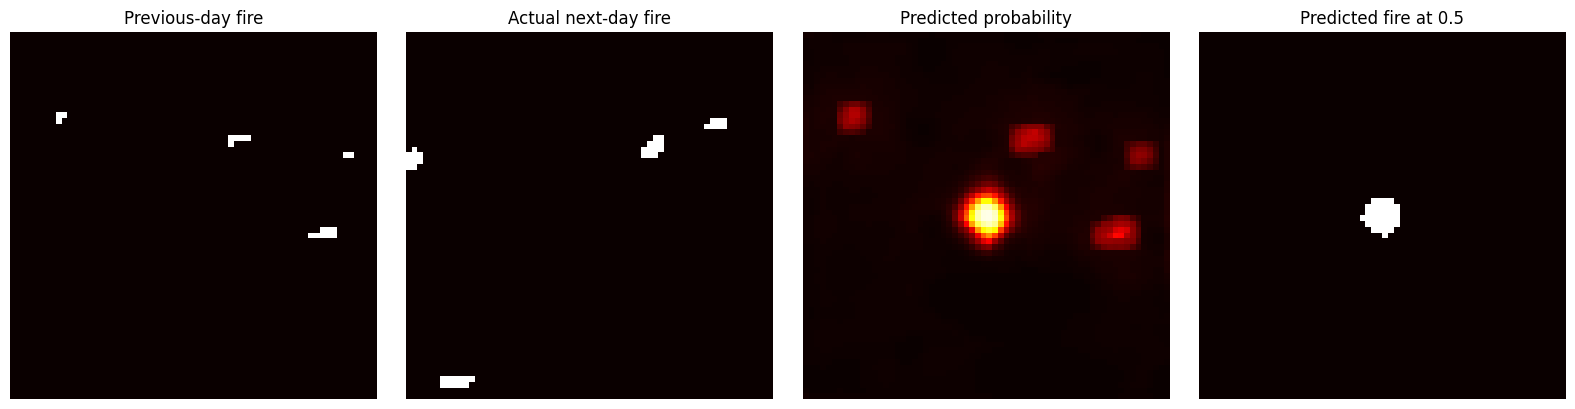

In [22]:
import matplotlib.pyplot as plt

# Pick a validation patch that contains at least one fire pixel.
sample_index = next(
    i
    for i, target in enumerate(val_loader.dataset.targets)
    if np.any(target == 1)
)

sample_input, sample_target, sample_mask = (
    val_loader.dataset[sample_index]
)

with torch.no_grad():
    sample_logits = model(
        sample_input.unsqueeze(0).to(device)
    )
    fire_probability = (
        torch.sigmoid(sample_logits)[0, 0].cpu().numpy()
    )

# The previous-day fire mask is normalized like the other inputs.
# Convert this channel back to its original values for display.
stats = NormalizationStats.load(STATS_PATH)
prev_channel = INPUT_FEATURES.index("PrevFireMask")

previous_fire = (
    sample_input[prev_channel].numpy() * stats.stds[prev_channel]
    + stats.means[prev_channel]
) > 0.5

valid_pixels = sample_mask[0].numpy() == 1
ground_truth = np.where(
    valid_pixels, sample_target[0].numpy(), np.nan
)
binary_prediction = np.where(
    valid_pixels, fire_probability >= THRESHOLD, np.nan
)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

images = [
    previous_fire,
    ground_truth,
    fire_probability,
    binary_prediction,
]
titles = [
    "Previous-day fire",
    "Actual next-day fire",
    "Predicted probability",
    "Predicted fire at 0.5",
]

for ax, image, title in zip(axes, images, titles):
    ax.imshow(image, cmap="hot", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()